# Notebook 04 — Repurchase Analysis

## Objetivo
Analisar a **recompra de clientes** no e-commerce Olist, conectando recorrência a tempo, ticket, parcelamento, meio de pagamento e categoria da primeira compra.

Este notebook diferencia duas leituras:

1. **Repeat order bruto**: cliente com pelo menos dois pedidos entregues em qualquer momento observado.
2. **Recompra em janela fixa**: cliente que realizou uma segunda compra em até 30, 60, 90 ou 180 dias após a primeira compra, considerando apenas clientes com janela de observação completa.

A segunda abordagem reduz o **viés de censura à direita**: clientes adquiridos no fim da base tiveram menos tempo para recomprar e não devem ser comparados diretamente com clientes antigos.

### Perguntas de negócio
- Qual é a taxa observada de clientes recorrentes?
- Em quanto tempo ocorre a segunda compra?
- Qual é a taxa de recompra ajustada em 30/60/90/180 dias?
- Meio de pagamento, parcelamento e ticket da primeira compra se associam à recompra?
- Quais categorias trazem clientes com maior retorno em até 90 dias?
- A segunda compra ocorre na mesma categoria ou amplia o relacionamento para outras categorias?
- Qual base deve alimentar um modelo de previsão de recompra sem vazamento temporal?

## 1. Configuração e carregamento

O notebook usa `orders_base.csv` do Notebook 01 e as tabelas raw necessárias para enriquecer a **primeira compra**.

No repositório GitHub, os arquivos raw devem ficar em `data/raw/`. Para a execução atual, há um fallback para `/mnt/data/olist_data`.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path('/mnt/data/olist_project') if Path('/mnt/data/olist_project').exists() else Path.cwd().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
FALLBACK_RAW_DIR = Path('/mnt/data/olist_data')


def raw_path(filename):
    p = RAW_DIR / filename
    if p.exists():
        return p
    fallback = FALLBACK_RAW_DIR / filename
    if fallback.exists():
        return fallback
    raise FileNotFoundError(f'Arquivo não encontrado: {filename}. Coloque-o em {RAW_DIR}')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('PROCESSED_DIR:', PROCESSED_DIR)

PROJECT_ROOT: /mnt/data/olist_project
PROCESSED_DIR: /mnt/data/olist_project/data/processed


In [2]:
orders_base = pd.read_csv(
    PROCESSED_DIR / 'orders_base.csv',
    parse_dates=['order_purchase_timestamp']
)

payments = pd.read_csv(raw_path('olist_order_payments_dataset.csv'))
order_items = pd.read_csv(raw_path('olist_order_items_dataset.csv'))
products = pd.read_csv(raw_path('olist_products_dataset.csv'))
category_translation = pd.read_csv(raw_path('product_category_name_translation.csv'))

print('orders_base:', orders_base.shape)
print('payments:', payments.shape)
print('order_items:', order_items.shape)
print('products:', products.shape)
print('category_translation:', category_translation.shape)

orders_base: (99441, 16)
payments: (103886, 5)
order_items: (112650, 7)
products: (32951, 9)
category_translation: (71, 2)


## 2. Universo analítico

Para estudar recorrência, usamos apenas pedidos:
- `order_status == delivered`;
- com `customer_unique_id` válido;
- com `order_purchase_timestamp` válido.

O identificador correto para acompanhar um cliente ao longo de múltiplos pedidos é `customer_unique_id`.

In [3]:
delivered = orders_base.loc[
    (orders_base['order_status'] == 'delivered') &
    orders_base['customer_unique_id'].notna() &
    orders_base['order_purchase_timestamp'].notna()
].copy()

delivered = delivered.sort_values(
    ['customer_unique_id', 'order_purchase_timestamp', 'order_id']
).reset_index(drop=True)

delivered['order_number'] = delivered.groupby('customer_unique_id').cumcount() + 1

dataset_end = delivered['order_purchase_timestamp'].max()
dataset_start = delivered['order_purchase_timestamp'].min()

print('Período entregue:', dataset_start, '→', dataset_end)
print('Pedidos entregues:', f'{len(delivered):,}')
print('Clientes únicos:', f"{delivered['customer_unique_id'].nunique():,}")
print('Pedidos por cliente — média:', round(len(delivered) / delivered['customer_unique_id'].nunique(), 4))

Período entregue: 2016-09-15 12:16:38 → 2018-08-29 15:00:37
Pedidos entregues: 96,478
Clientes únicos: 93,358
Pedidos por cliente — média: 1.0334


In [4]:
customer_order_counts = (
    delivered.groupby('customer_unique_id')['order_id']
    .nunique()
    .value_counts()
    .sort_index()
    .rename_axis('delivered_orders')
    .reset_index(name='customers')
)
customer_order_counts['customer_share'] = customer_order_counts['customers'] / customer_order_counts['customers'].sum()
display(customer_order_counts.head(10))

,delivered_orders,customers,customer_share
0,1,90557,0.9700
1,2,2573,0.0276
2,3,181,0.0019
3,4,28,0.0003
4,5,9,0.0001
5,6,5,0.0001
6,7,3,0.0000
7,9,1,0.0000
8,15,1,0.0000


## 3. Sequência de compras por cliente

A primeira e a segunda compras são extraídas diretamente da sequência temporal de pedidos entregues. O tempo até a segunda compra é medido em dias.

In [5]:
first_orders = delivered.loc[delivered['order_number'] == 1].copy()
second_orders = delivered.loc[delivered['order_number'] == 2, [
    'customer_unique_id', 'order_id', 'order_purchase_timestamp'
]].copy()

second_orders = second_orders.rename(columns={
    'order_id': 'second_order_id',
    'order_purchase_timestamp': 'second_purchase'
})

customer_repurchase = first_orders.merge(
    second_orders,
    on='customer_unique_id',
    how='left',
    validate='one_to_one'
)

customer_repurchase['repeat_customer'] = customer_repurchase['second_purchase'].notna()
customer_repurchase['days_to_second'] = (
    customer_repurchase['second_purchase'] - customer_repurchase['order_purchase_timestamp']
).dt.total_seconds() / 86400

customer_repurchase = customer_repurchase.rename(columns={
    'order_id': 'first_order_id',
    'order_purchase_timestamp': 'first_purchase',
    'payment_value': 'first_order_payment_value',
    'product_value': 'first_order_product_value',
    'freight_value': 'first_order_freight_value',
    'item_count': 'first_order_item_count',
    'distinct_products': 'first_order_distinct_products',
    'distinct_sellers': 'first_order_distinct_sellers'
})

raw_repeat_rate = customer_repurchase['repeat_customer'].mean()
print('Clientes:', f'{len(customer_repurchase):,}')
print('Clientes com 2+ pedidos entregues:', f"{customer_repurchase['repeat_customer'].sum():,}")
print('Taxa bruta de repeat order:', f'{raw_repeat_rate:.2%}')

Clientes: 93,358
Clientes com 2+ pedidos entregues: 2,801
Taxa bruta de repeat order: 3.00%


### Atenção: repetição muito rápida

Uma segunda ordem no mesmo dia pode representar uma recompra real, mas também pode refletir divisão de carrinho, compras complementares ou comportamento transacional muito próximo da primeira compra.

Por isso, o notebook mantém **qualquer segundo pedido** como definição principal de repeat order, mas apresenta uma análise de sensibilidade para retornos após 1 e 7 dias.

In [6]:
repeaters = customer_repurchase.loc[customer_repurchase['repeat_customer']].copy()

speed_summary = pd.DataFrame({
    'metric': [
        'Repeaters totais',
        'Segunda compra em até 1 dia',
        'Segunda compra em até 7 dias',
        'Segunda compra em até 30 dias',
        'Segunda compra em até 90 dias',
        'Segunda compra após 7 dias'
    ],
    'customers': [
        len(repeaters),
        (repeaters['days_to_second'] <= 1).sum(),
        (repeaters['days_to_second'] <= 7).sum(),
        (repeaters['days_to_second'] <= 30).sum(),
        (repeaters['days_to_second'] <= 90).sum(),
        (repeaters['days_to_second'] > 7).sum()
    ]
})
speed_summary['share_of_repeaters'] = speed_summary['customers'] / len(repeaters)
display(speed_summary)

,metric,customers,share_of_repeaters
0,Repeaters totais,2801,1.0000
1,Segunda compra em até 1 dia,853,0.3045
2,Segunda compra em até 7 dias,1015,0.3624
3,Segunda compra em até 30 dias,1412,0.5041
4,Segunda compra em até 90 dias,1907,0.6808
5,Segunda compra após 7 dias,1786,0.6376


count   2,801.0000
mean       81.2100
std       110.0000
min         0.0000
10%         0.0000
25%         0.0000
50%        28.9800
75%       126.2600
90%       246.3100
95%       324.0800
max       608.9800
Name: days_to_second, dtype: float64


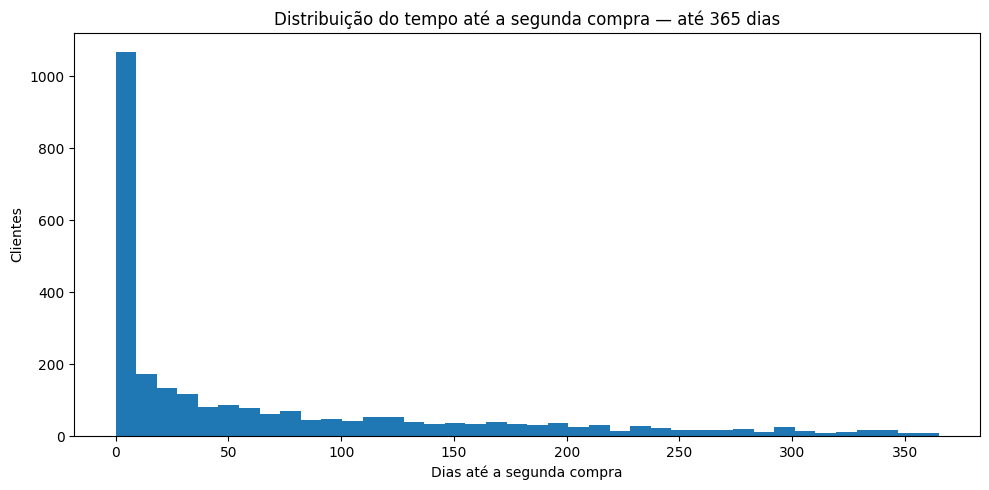

In [7]:
print(repeaters['days_to_second'].describe(percentiles=[.10, .25, .50, .75, .90, .95]).round(2))

plt.figure(figsize=(10, 5))
plot_days = repeaters.loc[repeaters['days_to_second'] <= 365, 'days_to_second']
plt.hist(plot_days, bins=40)
plt.title('Distribuição do tempo até a segunda compra — até 365 dias')
plt.xlabel('Dias até a segunda compra')
plt.ylabel('Clientes')
plt.tight_layout()
plt.show()

## 4. Recompra ajustada por janela de observação

Para uma janela de `H` dias:

- **Elegível**: primeira compra ocorreu pelo menos `H` dias antes do fim da base.
- **Recompra H dias**: segunda compra ocorreu até `H` dias após a primeira.

Essa é a métrica recomendada para comparações de comportamento e para a construção do modelo preditivo.

In [8]:
HORIZONS = [30, 60, 90, 180]
window_rows = []

for horizon in HORIZONS:
    eligible_col = f'eligible_{horizon}d'
    target_col = f'repurchase_{horizon}d'
    customer_repurchase[eligible_col] = (
        customer_repurchase['first_purchase'] <= dataset_end - pd.Timedelta(days=horizon)
    )
    customer_repurchase[target_col] = (
        customer_repurchase['second_purchase'].notna() &
        (customer_repurchase['second_purchase'] <= customer_repurchase['first_purchase'] + pd.Timedelta(days=horizon))
    )

    eligible = customer_repurchase[eligible_col]
    window_rows.append({
        'horizon_days': horizon,
        'eligible_customers': int(eligible.sum()),
        'repurchasing_customers': int(customer_repurchase.loc[eligible, target_col].sum()),
        'repurchase_rate': customer_repurchase.loc[eligible, target_col].mean()
    })

repurchase_window_summary = pd.DataFrame(window_rows)
display(repurchase_window_summary)

,horizon_days,eligible_customers,repurchasing_customers,repurchase_rate
0,30,86772,1373,0.0158
1,60,81203,1584,0.0195
2,90,75320,1714,0.0228
3,180,55907,1736,0.0311


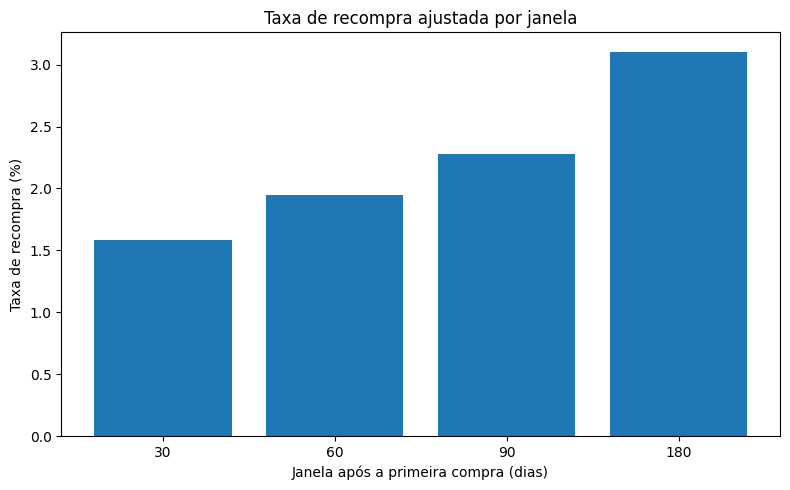

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(repurchase_window_summary['horizon_days'].astype(str), repurchase_window_summary['repurchase_rate'] * 100)
plt.title('Taxa de recompra ajustada por janela')
plt.xlabel('Janela após a primeira compra (dias)')
plt.ylabel('Taxa de recompra (%)')
plt.tight_layout()
plt.show()

,horizon_days,share_repeaters_within_horizon
0,1,0.3045
1,7,0.3624
2,30,0.5041
3,60,0.6094
4,90,0.6808
5,180,0.8268


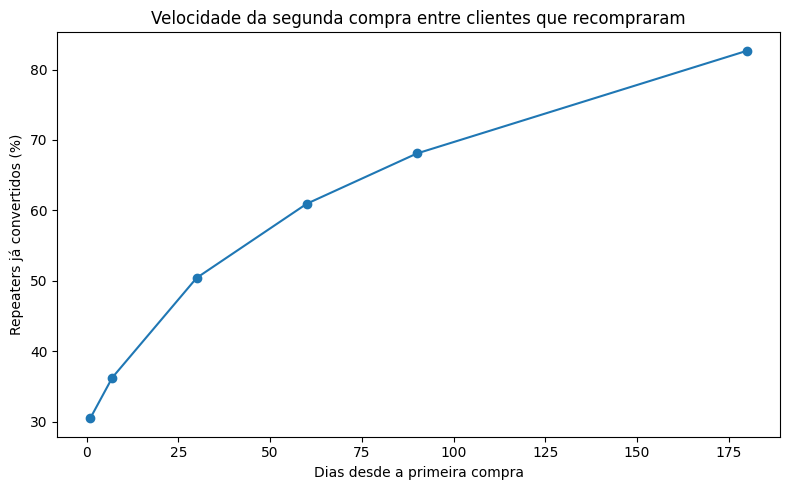

In [10]:
repeat_speed = pd.DataFrame({
    'horizon_days': [1, 7, 30, 60, 90, 180],
    'share_repeaters_within_horizon': [
        (repeaters['days_to_second'] <= h).mean() for h in [1, 7, 30, 60, 90, 180]
    ]
})
display(repeat_speed)

plt.figure(figsize=(8, 5))
plt.plot(repeat_speed['horizon_days'], repeat_speed['share_repeaters_within_horizon'] * 100, marker='o')
plt.title('Velocidade da segunda compra entre clientes que recompraram')
plt.xlabel('Dias desde a primeira compra')
plt.ylabel('Repeaters já convertidos (%)')
plt.tight_layout()
plt.show()

## 5. Enriquecimento da primeira compra — pagamento

Para pedidos com mais de um meio de pagamento, definimos `primary_payment_type` como o tipo com maior participação em valor no pedido.

Também extraímos:
- maior número de parcelas observado no pedido;
- quantidade de registros de pagamento;
- quantidade de tipos de pagamento usados.

In [11]:
payment_type_value = (
    payments.groupby(['order_id', 'payment_type'], as_index=False)['payment_value']
    .sum()
)

primary_idx = payment_type_value.groupby('order_id')['payment_value'].idxmax()
primary_payment = (
    payment_type_value.loc[primary_idx, ['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'primary_payment_type'})
)

payment_order_features = (
    payments.groupby('order_id', as_index=False)
    .agg(
        max_installments=('payment_installments', 'max'),
        payment_record_count=('payment_sequential', 'count'),
        payment_type_count=('payment_type', 'nunique')
    )
    .merge(primary_payment, on='order_id', how='left', validate='one_to_one')
)

display(payment_order_features.head())

,order_id,max_installments,payment_record_count,payment_type_count,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,2,1,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,3,1,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,5,1,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,2,1,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,3,1,1,credit_card


## 6. Enriquecimento da primeira compra — categoria

Como um pedido pode conter múltiplos produtos e categorias, definimos a **categoria dominante** como a categoria com maior soma de `price` dentro do pedido.

In [12]:
product_category = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

product_category['category'] = (
    product_category['product_category_name_english']
    .fillna(product_category['product_category_name'])
    .fillna('unknown')
)

items_enriched = order_items.merge(
    product_category[['product_id', 'category']],
    on='product_id',
    how='left',
    validate='many_to_one'
)
items_enriched['category'] = items_enriched['category'].fillna('unknown')

order_category_value = (
    items_enriched.groupby(['order_id', 'category'], as_index=False)['price']
    .sum()
)

category_idx = order_category_value.groupby('order_id')['price'].idxmax()
order_dominant_category = (
    order_category_value.loc[category_idx, ['order_id', 'category']]
    .rename(columns={'category': 'dominant_category'})
)

display(order_dominant_category.head())

,order_id,dominant_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [13]:
customer_repurchase = (
    customer_repurchase
    .merge(
        payment_order_features.rename(columns={'order_id': 'first_order_id'}),
        on='first_order_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        order_dominant_category.rename(columns={'order_id': 'first_order_id'}),
        on='first_order_id',
        how='left',
        validate='one_to_one'
    )
)

customer_repurchase['dominant_category'] = customer_repurchase['dominant_category'].fillna('unknown')
customer_repurchase['first_purchase_month'] = customer_repurchase['first_purchase'].dt.to_period('M').astype(str)
customer_repurchase['first_purchase_dow'] = customer_repurchase['first_purchase'].dt.day_name()
customer_repurchase['first_purchase_hour'] = customer_repurchase['first_purchase'].dt.hour
customer_repurchase['freight_ratio'] = np.where(
    customer_repurchase['first_order_payment_value'] > 0,
    customer_repurchase['first_order_freight_value'] / customer_repurchase['first_order_payment_value'],
    np.nan
)

print(customer_repurchase.shape)
display(customer_repurchase.head())

(93358, 38)


,first_order_id,customer_id,order_status,first_purchase,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,first_order_payment_value,payment_count,first_order_item_count,first_order_product_value,first_order_freight_value,first_order_distinct_products,first_order_distinct_sellers,order_number,second_order_id,second_purchase,repeat_customer,days_to_second,eligible_30d,repurchase_30d,eligible_60d,repurchase_60d,eligible_90d,repurchase_90d,eligible_180d,repurchase_180d,max_installments,payment_record_count,payment_type_count,primary_payment_type,dominant_category,first_purchase_month,first_purchase_dow,first_purchase_hour,freight_ratio
0,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21 00:00:00,0000366f3b9a7992bf8c76cfdf3221e2,141.9000,1.0000,1.0000,129.9000,12.0000,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,False,False,8.0000,1.0000,1.0000,credit_card,bed_bath_table,2018-05,Thursday,10,0.0846
1,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15 00:00:00,0000b849f77a49e4a4ce2b2a4ca5be3f,27.1900,1.0000,1.0000,18.9000,8.2900,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,False,False,1.0000,1.0000,1.0000,credit_card,health_beauty,2018-05,Monday,11,0.3049
2,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07 00:00:00,0000f46a3911fa3c0805444483337064,86.2200,1.0000,1.0000,69.0000,17.2200,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,8.0000,1.0000,1.0000,credit_card,stationery,2017-03,Friday,21,0.1997
3,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13 00:00:00,0000f6ccb0745a6a4b88665a16c9f078,43.6200,1.0000,1.0000,25.9900,17.6300,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,4.0000,1.0000,1.0000,credit_card,telephony,2017-10,Thursday,20,0.4042
4,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05 00:00:00,0004aac84e0df4da2b147fca70cf8255,196.8900,1.0000,1.0000,180.0000,16.8900,1.0000,1.0000,1,NaN,NaT,False,NaN,True,False,True,False,True,False,True,False,6.0000,1.0000,1.0000,credit_card,telephony,2017-11,Tuesday,19,0.0858


## 7. Meio de pagamento × recompra em 90 dias

A janela de **90 dias** será usada como referência principal porque:
- é longa o suficiente para capturar boa parte das recompras observadas;
- mantém uma amostra elegível grande;
- será uma definição adequada de target para o modelo preditivo posterior.

> Associação não implica causalidade. Diferenças por pagamento podem refletir ticket, categoria, perfil do cliente e outros fatores.

In [14]:
eligible_90 = customer_repurchase.loc[customer_repurchase['eligible_90d']].copy()

repurchase_by_payment = (
    eligible_90.groupby('primary_payment_type', dropna=False)
    .agg(
        customers=('customer_unique_id', 'size'),
        repurchasers_90d=('repurchase_90d', 'sum'),
        repurchase_rate_90d=('repurchase_90d', 'mean'),
        avg_first_ticket=('first_order_payment_value', 'mean'),
        median_first_ticket=('first_order_payment_value', 'median'),
        avg_installments=('max_installments', 'mean')
    )
    .reset_index()
    .sort_values('customers', ascending=False)
)
display(repurchase_by_payment)

,primary_payment_type,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket,median_first_ticket,avg_installments
1,credit_card,56848,1293,0.0227,166.2711,109.1800,3.5683
0,boleto,15303,343,0.0224,144.4438,93.2600,1.0000
3,voucher,2389,61,0.0255,116.0532,81.6300,1.1515
2,debit_card,779,17,0.0218,105.1394,77.6600,1.0000
4,NaN,1,0,0.0000,NaN,NaN,NaN


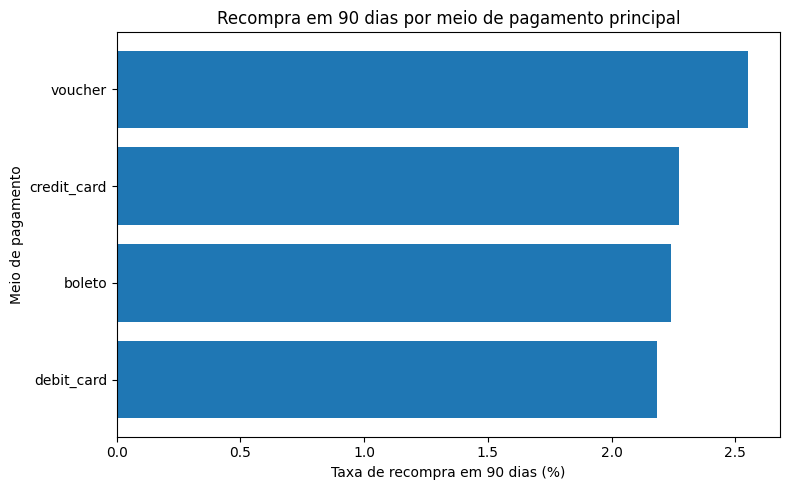

In [15]:
plot_df = repurchase_by_payment.loc[repurchase_by_payment['customers'] >= 100].sort_values('repurchase_rate_90d')
plt.figure(figsize=(8, 5))
plt.barh(plot_df['primary_payment_type'], plot_df['repurchase_rate_90d'] * 100)
plt.title('Recompra em 90 dias por meio de pagamento principal')
plt.xlabel('Taxa de recompra em 90 dias (%)')
plt.ylabel('Meio de pagamento')
plt.tight_layout()
plt.show()

## 8. Parcelamento × recompra em 90 dias

Faixas de parcelas são usadas para facilitar leitura executiva. A faixa `13+x` deve ser interpretada com cautela se tiver baixa amostra.

In [16]:
installment_bins = [-1, 1, 3, 6, 12, np.inf]
installment_labels = ['1x', '2–3x', '4–6x', '7–12x', '13+x']

customer_repurchase['installment_band'] = pd.cut(
    customer_repurchase['max_installments'],
    bins=installment_bins,
    labels=installment_labels
)

eligible_90 = customer_repurchase.loc[customer_repurchase['eligible_90d']].copy()

repurchase_by_installment = (
    eligible_90.groupby('installment_band', observed=True)
    .agg(
        customers=('customer_unique_id', 'size'),
        repurchasers_90d=('repurchase_90d', 'sum'),
        repurchase_rate_90d=('repurchase_90d', 'mean'),
        avg_first_ticket=('first_order_payment_value', 'mean')
    )
    .reset_index()
)
display(repurchase_by_installment)

,installment_band,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
0,1x,36336,760,0.0209,120.0967
1,2–3x,17393,385,0.0221,134.5602
2,4–6x,12338,283,0.0229,179.7619
3,7–12x,9126,280,0.0307,333.5374
4,13+x,126,6,0.0476,442.4820


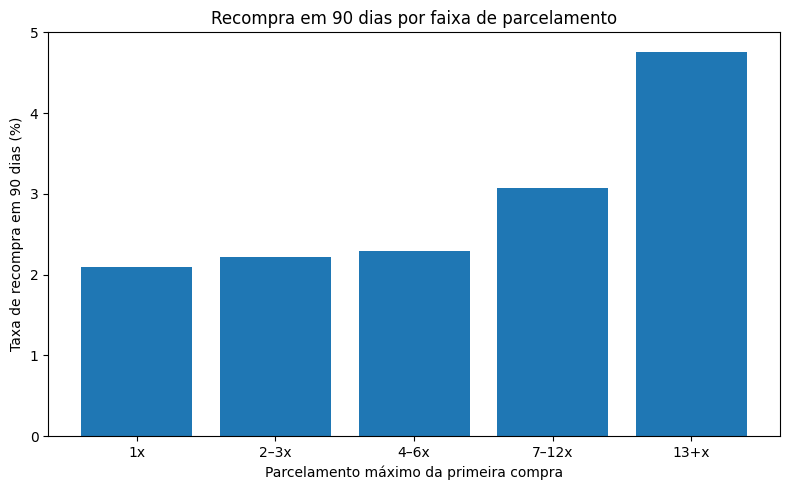

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(repurchase_by_installment['installment_band'].astype(str), repurchase_by_installment['repurchase_rate_90d'] * 100)
plt.title('Recompra em 90 dias por faixa de parcelamento')
plt.xlabel('Parcelamento máximo da primeira compra')
plt.ylabel('Taxa de recompra em 90 dias (%)')
plt.tight_layout()
plt.show()

## 9. Ticket da primeira compra × recompra

Para evitar faixas arbitrárias, o ticket é dividido em **quintis dentro da população elegível para 90 dias**.

In [18]:
eligible_90 = customer_repurchase.loc[customer_repurchase['eligible_90d']].copy()
eligible_90['ticket_quintile'] = pd.qcut(
    eligible_90['first_order_payment_value'],
    q=5,
    labels=['Q1 — menor', 'Q2', 'Q3', 'Q4', 'Q5 — maior'],
    duplicates='drop'
)

repurchase_by_ticket = (
    eligible_90.groupby('ticket_quintile', observed=True)
    .agg(
        customers=('customer_unique_id', 'size'),
        repurchasers_90d=('repurchase_90d', 'sum'),
        repurchase_rate_90d=('repurchase_90d', 'mean'),
        avg_first_ticket=('first_order_payment_value', 'mean')
    )
    .reset_index()
)
display(repurchase_by_ticket)

,ticket_quintile,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
0,Q1 — menor,15068,369,0.0245,39.2012
1,Q2,15137,329,0.0217,69.0131
2,Q3,14989,412,0.0275,105.3601
3,Q4,15063,278,0.0185,159.9898
4,Q5 — maior,15062,326,0.0216,424.7280


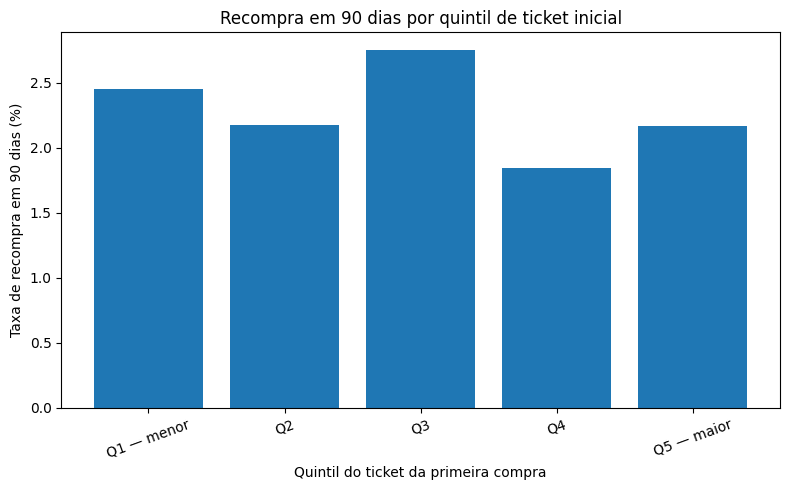

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(repurchase_by_ticket['ticket_quintile'].astype(str), repurchase_by_ticket['repurchase_rate_90d'] * 100)
plt.title('Recompra em 90 dias por quintil de ticket inicial')
plt.xlabel('Quintil do ticket da primeira compra')
plt.ylabel('Taxa de recompra em 90 dias (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Categoria da primeira compra × recompra em 90 dias

Para reduzir ruído de amostras pequenas, a comparação executiva destaca categorias com pelo menos **300 clientes elegíveis**.

In [20]:
repurchase_by_category = (
    eligible_90.groupby('dominant_category')
    .agg(
        customers=('customer_unique_id', 'size'),
        repurchasers_90d=('repurchase_90d', 'sum'),
        repurchase_rate_90d=('repurchase_90d', 'mean'),
        avg_first_ticket=('first_order_payment_value', 'mean')
    )
    .reset_index()
)

category_min_sample = 300
category_comparison = (
    repurchase_by_category.loc[repurchase_by_category['customers'] >= category_min_sample]
    .sort_values('repurchase_rate_90d', ascending=False)
)

display(category_comparison.head(20))

,dominant_category,customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
44,home_appliances,494,38,0.0769,137.2451
28,fashion_bags_accessories,1434,63,0.0439,99.7655
7,bed_bath_table,7126,282,0.0396,133.1213
39,furniture_decor,4976,175,0.0352,137.5543
67,sports_leisure,6040,173,0.0286,149.6393
17,construction_tools_construction,388,9,0.0232,234.4116
43,health_beauty,6177,140,0.0227,162.5476
15,computers_accessories,5223,114,0.0218,163.1978
61,pet_shop,1185,24,0.0203,143.5611
65,small_appliances,495,10,0.0202,322.6135


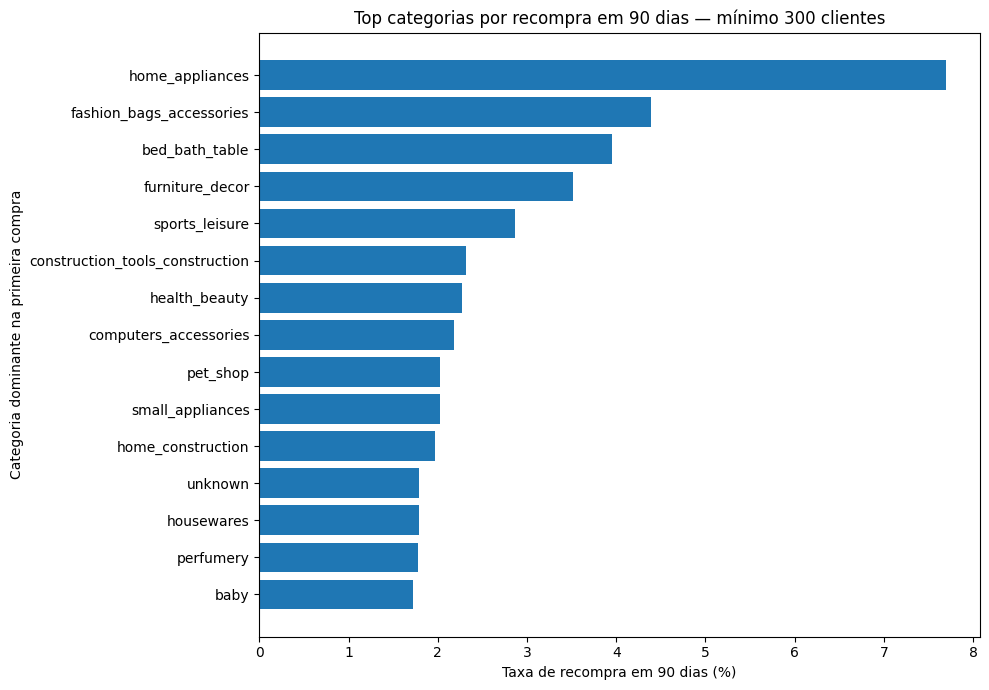

In [21]:
plot_cat = category_comparison.head(15).sort_values('repurchase_rate_90d')
plt.figure(figsize=(10, 7))
plt.barh(plot_cat['dominant_category'], plot_cat['repurchase_rate_90d'] * 100)
plt.title(f'Top categorias por recompra em 90 dias — mínimo {category_min_sample} clientes')
plt.xlabel('Taxa de recompra em 90 dias (%)')
plt.ylabel('Categoria dominante na primeira compra')
plt.tight_layout()
plt.show()

## 11. Mesma categoria ou expansão de relacionamento?

Entre clientes que fizeram uma segunda compra, comparamos a categoria dominante do primeiro e do segundo pedido.

In [22]:
second_category = order_dominant_category.rename(columns={
    'order_id': 'second_order_id',
    'dominant_category': 'second_dominant_category'
})

repeat_category = (
    customer_repurchase.loc[customer_repurchase['repeat_customer'], [
        'customer_unique_id', 'dominant_category', 'second_order_id', 'days_to_second'
    ]]
    .merge(second_category, on='second_order_id', how='left', validate='many_to_one')
)

repeat_category['second_dominant_category'] = repeat_category['second_dominant_category'].fillna('unknown')
repeat_category['same_category'] = (
    repeat_category['dominant_category'] == repeat_category['second_dominant_category']
)

same_category_rate = repeat_category['same_category'].mean()
print('Repeaters com segunda compra na mesma categoria dominante:', f'{same_category_rate:.2%}')
print('Repeaters com segunda compra em categoria diferente:', f'{1-same_category_rate:.2%}')

Repeaters com segunda compra na mesma categoria dominante: 45.98%
Repeaters com segunda compra em categoria diferente: 54.02%


In [23]:
category_transition = (
    repeat_category.groupby(['dominant_category', 'second_dominant_category'])
    .size()
    .reset_index(name='customers')
    .sort_values('customers', ascending=False)
)

display(category_transition.head(20))

transition_summary = pd.DataFrame({
    'transition_type': ['Mesma categoria', 'Categoria diferente'],
    'customers': [repeat_category['same_category'].sum(), (~repeat_category['same_category']).sum()]
})
transition_summary['share'] = transition_summary['customers'] / transition_summary['customers'].sum()
display(transition_summary)

,dominant_category,second_dominant_category,customers
66,bed_bath_table,bed_bath_table,222
559,sports_leisure,sports_leisure,160
365,health_beauty,health_beauty,138
292,furniture_decor,furniture_decor,118
113,computers_accessories,computers_accessories,117
667,watches_gifts,watches_gifts,59
421,housewares,housewares,53
383,home_appliances,home_appliances,49
224,fashion_bags_accessories,fashion_bags_accessories,44
599,telephony,telephony,42


,transition_type,customers,share
0,Mesma categoria,1288,0.4598
1,Categoria diferente,1513,0.5402


## 12. Coorte de aquisição × recompra em 90 dias

Esta é uma leitura simples de maturidade da aquisição. O Notebook 05 aprofundará retenção por coorte em formato matricial.

In [24]:
cohort_90d = (
    customer_repurchase.loc[customer_repurchase['eligible_90d']]
    .groupby('first_purchase_month')
    .agg(
        acquired_customers=('customer_unique_id', 'size'),
        repurchasers_90d=('repurchase_90d', 'sum'),
        repurchase_rate_90d=('repurchase_90d', 'mean'),
        avg_first_ticket=('first_order_payment_value', 'mean')
    )
    .reset_index()
    .sort_values('first_purchase_month')
)

display(cohort_90d.tail(18))

,first_purchase_month,acquired_customers,repurchasers_90d,repurchase_rate_90d,avg_first_ticket
2,2016-12,1,1,1.0000,19.6200
3,2017-01,717,26,0.0363,173.7982
4,2017-02,1628,28,0.0172,164.7097
5,2017-03,2503,62,0.0248,163.6477
6,2017-04,2256,48,0.0213,170.0463
7,2017-05,3451,98,0.0284,159.8338
8,2017-06,3037,86,0.0283,157.4396
9,2017-07,3752,97,0.0259,146.5829
10,2017-08,4057,112,0.0276,153.8894
11,2017-09,4004,114,0.0285,169.9786


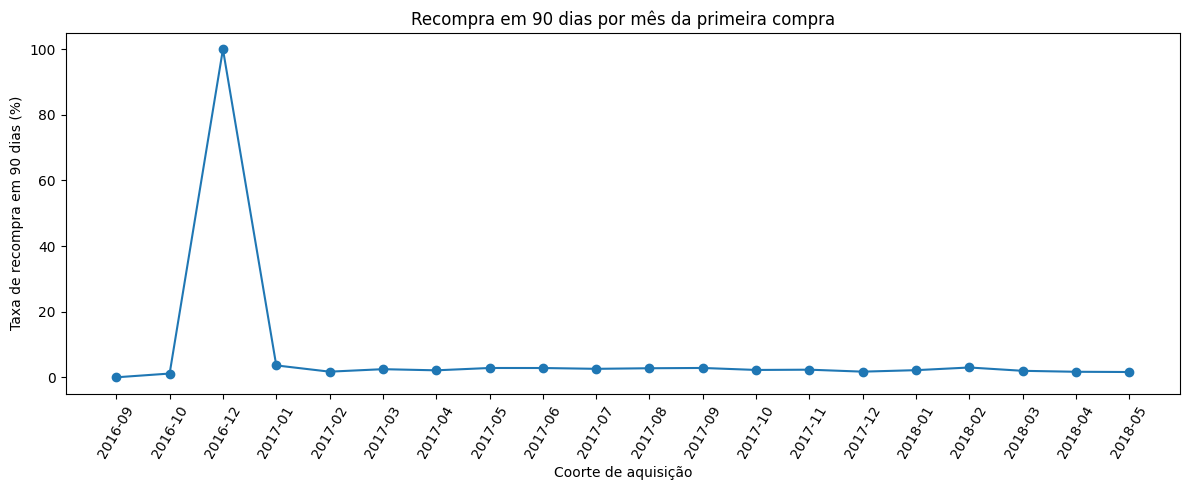

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(cohort_90d['first_purchase_month'], cohort_90d['repurchase_rate_90d'] * 100, marker='o')
plt.title('Recompra em 90 dias por mês da primeira compra')
plt.xlabel('Coorte de aquisição')
plt.ylabel('Taxa de recompra em 90 dias (%)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 13. Base pronta para modelagem preditiva de recompra em 90 dias

Para o futuro Notebook 06, a população de modelagem deve conter somente clientes cuja primeira compra ocorreu pelo menos 90 dias antes do fim da base.

As features abaixo são conhecidas **no momento da primeira compra**. O target é `repurchase_90d`.

Isso evita usar informações futuras como recência atual, frequência total ou valor monetário acumulado, que provocariam **data leakage**.

In [26]:
model_columns = [
    'customer_unique_id',
    'first_order_id',
    'first_purchase',
    'first_order_payment_value',
    'first_order_product_value',
    'first_order_freight_value',
    'first_order_item_count',
    'first_order_distinct_products',
    'first_order_distinct_sellers',
    'freight_ratio',
    'primary_payment_type',
    'max_installments',
    'payment_record_count',
    'payment_type_count',
    'dominant_category',
    'first_purchase_month',
    'first_purchase_dow',
    'first_purchase_hour',
    'repurchase_90d'
]

repurchase_90d_model_base = (
    customer_repurchase.loc[customer_repurchase['eligible_90d'], model_columns]
    .copy()
    .sort_values('first_purchase')
    .reset_index(drop=True)
)

print('Model base:', repurchase_90d_model_base.shape)
print('Target rate:', f"{repurchase_90d_model_base['repurchase_90d'].mean():.2%}")
display(repurchase_90d_model_base.head())

Model base: (75320, 19)
Target rate: 2.28%


,customer_unique_id,first_order_id,first_purchase,first_order_payment_value,first_order_product_value,first_order_freight_value,first_order_item_count,first_order_distinct_products,first_order_distinct_sellers,freight_ratio,primary_payment_type,max_installments,payment_record_count,payment_type_count,dominant_category,first_purchase_month,first_purchase_dow,first_purchase_hour,repurchase_90d
0,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,NaN,134.9700,8.4900,3.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,health_beauty,2016-09,Thursday,12,False
1,32ea3bdedab835c3aa6cb68ce66565ef,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,45.4600,29.9000,15.5600,1.0000,1.0000,1.0000,0.3423,boleto,1.0000,1.0000,1.0000,watches_gifts,2016-10,Monday,9,False
2,2f64e403852e6893ae37485d5fcacdaf,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,39.0900,21.9000,17.1900,1.0000,1.0000,1.0000,0.4398,boleto,1.0000,1.0000,1.0000,sports_leisure,2016-10,Monday,16,False
3,61db744d2f835035a5625b59350c6b63,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,53.7300,36.4900,17.2400,1.0000,1.0000,1.0000,0.3209,boleto,1.0000,1.0000,1.0000,sports_leisure,2016-10,Monday,21,False
4,8d3a54507421dbd2ce0a1d58046826e0,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,133.4600,119.9000,13.5600,1.0000,1.0000,1.0000,0.1016,credit_card,6.0000,1.0000,1.0000,furniture_decor,2016-10,Monday,22,False


### Split temporal recomendado

No modelo de recompra, não usar `train_test_split` aleatório como estratégia principal. O correto é ordenar pela data da primeira compra e treinar com clientes mais antigos, validando em coortes posteriores.

Uma forma simples:
- **Treino**: primeiros 70–80% dos clientes por `first_purchase`;
- **Teste**: 20–30% mais recentes ainda com janela de 90 dias completa.

Também será importante tratar o forte desbalanceamento do target: a recompra em 90 dias é rara.

In [27]:
cut_idx = int(len(repurchase_90d_model_base) * 0.80)
temporal_train = repurchase_90d_model_base.iloc[:cut_idx]
temporal_test = repurchase_90d_model_base.iloc[cut_idx:]

print('Treino:', temporal_train['first_purchase'].min(), '→', temporal_train['first_purchase'].max(), temporal_train.shape)
print('Teste :', temporal_test['first_purchase'].min(), '→', temporal_test['first_purchase'].max(), temporal_test.shape)
print('Target treino:', f"{temporal_train['repurchase_90d'].mean():.2%}")
print('Target teste :', f"{temporal_test['repurchase_90d'].mean():.2%}")

Treino: 2016-09-15 12:16:38 → 2018-03-21 20:09:23 (60256, 19)
Teste : 2018-03-21 20:18:05 → 2018-05-31 14:38:55 (15064, 19)
Target treino: 2.42%
Target teste : 1.69%


## 14. KPIs executivos

In [28]:
median_days_to_second = repeaters['days_to_second'].median()
share_repeaters_30d = (repeaters['days_to_second'] <= 30).mean()
share_repeaters_90d = (repeaters['days_to_second'] <= 90).mean()
repurchase_90_rate = repurchase_window_summary.loc[
    repurchase_window_summary['horizon_days'] == 90, 'repurchase_rate'
].iloc[0]
repurchase_180_rate = repurchase_window_summary.loc[
    repurchase_window_summary['horizon_days'] == 180, 'repurchase_rate'
].iloc[0]

executive_kpis = pd.DataFrame({
    'kpi': [
        'customers_delivered',
        'repeat_customers_any_time',
        'raw_repeat_rate',
        'median_days_to_second_purchase',
        'share_repeaters_within_30d',
        'share_repeaters_within_90d',
        'repurchase_rate_90d_adjusted',
        'repurchase_rate_180d_adjusted',
        'same_category_share_second_purchase'
    ],
    'value': [
        len(customer_repurchase),
        int(customer_repurchase['repeat_customer'].sum()),
        raw_repeat_rate,
        median_days_to_second,
        share_repeaters_30d,
        share_repeaters_90d,
        repurchase_90_rate,
        repurchase_180_rate,
        same_category_rate
    ]
})
display(executive_kpis)

,kpi,value
0,customers_delivered,"93,358.0000"
1,repeat_customers_any_time,"2,801.0000"
2,raw_repeat_rate,0.0300
3,median_days_to_second_purchase,28.9802
4,share_repeaters_within_30d,0.5041
5,share_repeaters_within_90d,0.6808
6,repurchase_rate_90d_adjusted,0.0228
7,repurchase_rate_180d_adjusted,0.0311
8,same_category_share_second_purchase,0.4598


In [29]:
print('LEITURA EXECUTIVA')
print('-' * 80)
print(f"1. Apenas {raw_repeat_rate:.2%} dos clientes observados fizeram 2+ pedidos entregues no período total.")
print(f"2. Corrigindo a janela de observação, a recompra em 90 dias é {repurchase_90_rate:.2%} e em 180 dias é {repurchase_180_rate:.2%}.")
print(f"3. Entre quem recompra, a mediana do tempo até a segunda compra é {median_days_to_second:.1f} dias.")
print(f"4. {share_repeaters_30d:.1%} dos repeaters já realizaram a segunda compra em até 30 dias; {share_repeaters_90d:.1%} em até 90 dias.")
print(f"5. {same_category_rate:.1%} dos repeaters permanecem na mesma categoria dominante na segunda compra; o restante migra para outra categoria.")
print('6. Diferenças por pagamento, parcelamento e categoria são sinais de segmentação — não evidência causal.')
print('7. A maior oportunidade é aumentar a conversão da primeira para a segunda compra dentro dos primeiros 30–90 dias.')

LEITURA EXECUTIVA
--------------------------------------------------------------------------------
1. Apenas 3.00% dos clientes observados fizeram 2+ pedidos entregues no período total.
2. Corrigindo a janela de observação, a recompra em 90 dias é 2.28% e em 180 dias é 3.11%.
3. Entre quem recompra, a mediana do tempo até a segunda compra é 29.0 dias.
4. 50.4% dos repeaters já realizaram a segunda compra em até 30 dias; 68.1% em até 90 dias.
5. 46.0% dos repeaters permanecem na mesma categoria dominante na segunda compra; o restante migra para outra categoria.
6. Diferenças por pagamento, parcelamento e categoria são sinais de segmentação — não evidência causal.
7. A maior oportunidade é aumentar a conversão da primeira para a segunda compra dentro dos primeiros 30–90 dias.


## 15. Recomendações para storytelling executivo

### Tese 1 — O principal gargalo é transformar aquisição em relacionamento
A base apresenta uma recorrência baixa. Isso sugere dependência elevada de aquisição de novos clientes e limita o valor acumulado por cliente.

### Tese 2 — A janela pós-primeira compra deve ser tratada como momento crítico
Uma parcela relevante dos clientes que eventualmente recompram o faz nos primeiros 30–90 dias. Portanto, campanhas de segunda compra devem ser concentradas nessa janela.

### Tese 3 — Categoria inicial importa
Categorias com maior taxa ajustada de recompra podem funcionar como portas de entrada para relacionamento. Categorias com alta aquisição, mas baixo retorno, exigem estratégias específicas de cross-sell e remarketing.

### Tese 4 — Quase metade das segundas compras ocorre na mesma categoria
Isso permite combinar duas estratégias:
- **reposição/continuidade** para categorias naturalmente recorrentes;
- **cross-sell** para clientes com potencial de expansão de cesta.

### Tese 5 — Pagamento e parcelamento são sinais, não causas
Meio de pagamento, número de parcelas e ticket podem ser úteis como features de propensão, mas devem ser avaliados conjuntamente com categoria e momento da aquisição em um modelo multivariado.

## 16. Exportação das camadas analíticas

In [30]:
exports = {
    'repurchase_customer_level.csv': customer_repurchase,
    'repurchase_window_summary.csv': repurchase_window_summary,
    'repurchase_by_payment_type_90d.csv': repurchase_by_payment,
    'repurchase_by_installments_90d.csv': repurchase_by_installment,
    'repurchase_by_ticket_90d.csv': repurchase_by_ticket,
    'repurchase_by_first_category_90d.csv': repurchase_by_category,
    'repurchase_category_transition.csv': category_transition,
    'repurchase_cohort_90d.csv': cohort_90d,
    'repurchase_90d_model_base.csv': repurchase_90d_model_base,
    'repurchase_executive_kpis.csv': executive_kpis
}

for filename, df in exports.items():
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False)
    print('Exportado:', path, df.shape)

Exportado: /mnt/data/olist_project/data/processed/repurchase_customer_level.csv (93358, 39)
Exportado: /mnt/data/olist_project/data/processed/repurchase_window_summary.csv (4, 4)
Exportado: /mnt/data/olist_project/data/processed/repurchase_by_payment_type_90d.csv (5, 7)
Exportado: /mnt/data/olist_project/data/processed/repurchase_by_installments_90d.csv (5, 5)
Exportado: /mnt/data/olist_project/data/processed/repurchase_by_ticket_90d.csv (5, 5)
Exportado: /mnt/data/olist_project/data/processed/repurchase_by_first_category_90d.csv (74, 5)
Exportado: /mnt/data/olist_project/data/processed/repurchase_category_transition.csv (668, 3)
Exportado: /mnt/data/olist_project/data/processed/repurchase_cohort_90d.csv (20, 5)


Exportado: /mnt/data/olist_project/data/processed/repurchase_90d_model_base.csv (75320, 19)
Exportado: /mnt/data/olist_project/data/processed/repurchase_executive_kpis.csv (9, 2)


## 17. Sanity checks

In [31]:
assert customer_repurchase['customer_unique_id'].is_unique, 'A base customer-level deve ter uma linha por cliente.'
assert (customer_repurchase['days_to_second'].dropna() >= 0).all(), 'Há segunda compra anterior à primeira.'
assert repurchase_90d_model_base['repurchase_90d'].notna().all(), 'Target de 90 dias não pode ser nulo.'
assert repurchase_90d_model_base['first_purchase'].max() <= dataset_end - pd.Timedelta(days=90), 'Há cliente sem janela completa de 90 dias na model base.'
assert customer_repurchase['first_order_id'].is_unique, 'Primeiro pedido deveria ser único por cliente.'
assert (repurchase_window_summary['repurchase_rate'].between(0, 1)).all(), 'Taxas fora do intervalo [0,1].'

print('Sanity checks concluídos com sucesso.')

Sanity checks concluídos com sucesso.


## Conclusão

O Notebook 04 transforma a recorrência em uma métrica temporalmente comparável e prepara o projeto para duas frentes:

1. **Notebook 05 — Cohort Analysis:** retenção por mês de aquisição e evolução temporal.
2. **Notebook 06 — Repurchase Prediction:** previsão de recompra em 90 dias usando apenas sinais disponíveis na primeira compra e validação temporal.

A recomendação executiva central é medir e otimizar a **conversão da primeira para a segunda compra**, especialmente nos primeiros 30–90 dias, em vez de analisar apenas a taxa bruta de clientes recorrentes.